<a href="https://colab.research.google.com/github/Alfonso-Jesus-Garcia-Moya/LINGUISTICA_COMPUTACIONAL/blob/Sesion-4-Manejo-de-Cr%C3%ADticas-y-Comentario_n%C3%A1lisis-de-Estad%C3%ADsticas-y-M%C3%A9tricas_-Resumen-y-Comparaci%C3%B3n/Sesion_4_Manejo_de_Cr%C3%ADticas_y_Comentario_n%C3%A1lisis_de_Estad%C3%ADsticas_y_M%C3%A9tricas__Resumen_y_Comparaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SCRIPT MODIFICADO PARA 10 COMENTARIOS EJEMPLO DE MI PERFIL

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Script de Análisis de Perfil de Autor
Adaptado para ejecutar todas las técnicas con un conjunto de comentarios personalizados.
"""

# =============================================================================
# PASO 0: INSTALAR LIBRERÍAS (si no lo has hecho)
# =============================================================================
# pip install transformers torch pysentimiento scikit-learn gensim nltk networkx matplotlib

# =============================================================================
# PASO 1: IMPORTAR TODO LO NECESARIO
# =============================================================================
import itertools
import networkx as nx
import matplotlib.pyplot as plt
import gensim
from gensim import corpora
import nltk
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from pysentimiento import create_analyzer
from transformers import pipeline

# Descargas necesarias para NLTK (solo se ejecutan la primera vez)
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

# =============================================================================
# PASO 2: TUS DATOS - 10 COMENTARIOS REALES DE TU PERFIL
# =============================================================================
mis_comentarios = [
    "¡Qué gran explicación! Por fin entendí la diferencia entre deep learning y machine learning.",
    "El audio del micrófono se escucha un poco bajo en este video, pero el contenido es oro.",
    "¿Podrías hacer un tutorial sobre cómo usar la API de OpenAI? Sería genial.",
    "Muchas gracias por compartir tu conocimiento, me ha servido para un proyecto de la universidad.",
    "No estoy de acuerdo con el punto sobre las redes neuronales recurrentes, hay enfoques más modernos.",
    "Excelente aporte. Directo y al punto.",
    "Me suscribo. Tienes una forma muy clara de enseñar temas complejos.",
    "El enlace al repositorio de GitHub está roto, ¿podrías arreglarlo?",
    "¡Brutal! Ojalá hubiera encontrado este canal cuando empecé a estudiar.",
    "Un tema aceptable, aunque esperaba un análisis más profundo."
]

print("🚀 INICIANDO ANÁLISIS DE PERFIL CON 10 COMENTARIOS 🚀")

# =============================================================================
# SECCIÓN 1: ANÁLISIS DE SENTIMIENTOS
# =============================================================================
print("\n\n" + "="*20 + " 1. ANÁLISIS DE SENTIMIENTOS " + "="*20)
sentiment_analyzer = pipeline("sentiment-analysis", model="pysentimiento/robertuito-sentiment-analysis")
for c in mis_comentarios:
    resultado = sentiment_analyzer(c)
    print(f"'{c}' -> {resultado}")

# =============================================================================
# SECCIÓN 2: DETECCIÓN DE EMOCIONES
# =============================================================================
print("\n\n" + "="*20 + " 2. DETECCIÓN DE EMOCIONES " + "="*20)
emotion_analyzer = create_analyzer(task="emotion", lang="es")
for c in mis_comentarios:
    resultado = emotion_analyzer.predict(c)
    print(f"'{c}' -> Emoción: {resultado.output} | Probabilidades: {resultado.probas}")

# =============================================================================
# SECCIÓN 3: CLASIFICACIÓN DE SPAM/TROLLS
# =============================================================================
print("\n\n" + "="*20 + " 3. CLASIFICACIÓN DE SPAM " + "="*20)
# Entrenamos un modelo con TUS comentarios, asumiendo que todos son "normales".
labels = ["normal"] * len(mis_comentarios)
vectorizer_spam = CountVectorizer()
X_train = vectorizer_spam.fit_transform(mis_comentarios)
clf = MultinomialNB()
clf.fit(X_train, labels)

# Probamos con nuevos comentarios de ejemplo para ver cómo los clasifica.
nuevos_ejemplos = ["Sígueme para ganar premios", "Muy buen video, felicidades"]
X_new = vectorizer_spam.transform(nuevos_ejemplos)
predicciones = clf.predict(X_new)
print("Clasificación de nuevos comentarios de prueba:")
for comentario, prediccion in zip(nuevos_ejemplos, predicciones):
    print(f"'{comentario}' -> {prediccion}")

# =============================================================================
# SECCIÓN 4: ANÁLISIS DE TEMAS (LDA)
# =============================================================================
print("\n\n" + "="*20 + " 4. ANÁLISIS DE TEMAS (LDA) " + "="*20)
# Tokenización (convertir comentarios en listas de palabras)
texts = [word_tokenize(doc.lower()) for doc in mis_comentarios]
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Modelo LDA con 2 temas
lda_model = gensim.models.LdaModel(corpus, num_topics=2, id2word=dictionary, passes=15)
print("Temas detectados en tus comentarios:")
for idx, topic in lda_model.print_topics():
    print(f"Tema {idx}: {topic}")

# =============================================================================
# SECCIÓN 5: ANÁLISIS DE CO-OCURRENCIAS
# =============================================================================
print("\n\n" + "="*20 + " 5. RED DE CO-OCURRENCIAS " + "="*20)
# Usamos los 'texts' de la sección anterior que ya están tokenizados
edges = []
for toks in texts:
    # Filtramos palabras muy cortas para una mejor visualización
    toks_filtrados = [tok for tok in toks if len(tok) > 2]
    if len(toks_filtrados) > 1:
        edges += list(itertools.combinations(toks_filtrados, 2))

G = nx.Graph()
G.add_edges_from(edges)

plt.figure(figsize=(8, 6))
nx.draw(G, with_labels=True, node_size=2000, node_color="#a7c7e7", font_size=10, width=1.5)
plt.title("Red de Co-ocurrencias de Palabras en tus Comentarios")
print("Mostrando gráfico de la red de co-ocurrencias...")
plt.show()

# =============================================================================
# SECCIÓN 6: RESUMEN AUTOMÁTICO
# =============================================================================
print("\n\n" + "="*20 + " 6. RESUMEN AUTOMÁTICO " + "="*20)
# Unimos todos los comentarios en un solo texto
texto_largo = " ".join(mis_comentarios)
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
resumen = summarizer(texto_largo, max_length=60, min_length=20, do_sample=False)
print("Resumen generado a partir de todos tus comentarios:")
print(resumen[0]["summary_text"])

# =============================================================================
# SECCIÓN 7: ANÁLISIS COMPARATIVO (TF-IDF)
# =============================================================================
print("\n\n" + "="*20 + " 7. ANÁLISIS COMPARATIVO (EJEMPLO) " + "="*20)
# NOTA: Esta sección se mantiene con los perfiles de ejemplo para demostrar
# la comparación entre dos temas distintos (programación vs. ciberseguridad),
# como en el script original.
perfil_A = [
    "Curso de Python aplicado a ciencia de datos",
    "Introducción a machine learning con ejemplos prácticos",
    "Estadística aplicada para análisis de datos"
]
perfil_B = [
    "Taller de ciberseguridad en redes sociales",
    "Cómo proteger datos personales en internet",
    "Privacidad y seguridad digital para empresas"
]
stopwords_es = ["de", "a", "en", "para", "con", "por", "como", "los", "las", "un", "una", "y", "el", "la", "lo", "es", "al", "del", "se"]
corpus_ejemplo = perfil_A + perfil_B
vectorizer_tfidf = TfidfVectorizer(stop_words=stopwords_es)
X_tfidf = vectorizer_tfidf.fit_transform(corpus_ejemplo)
terminos = vectorizer_tfidf.get_feature_names_out()
puntajes_A = X_tfidf.toarray()[:len(perfil_A)].sum(axis=0)
puntajes_B = X_tfidf.toarray()[len(perfil_A):].sum(axis=0)
ranking_A = sorted(zip(terminos, puntajes_A), key=lambda x: x[1], reverse=True)[:5]
ranking_B = sorted(zip(terminos, puntajes_B), key=lambda x: x[1], reverse=True)[:5]

print("🔹 Palabras clave del Perfil de Ejemplo A (programación/datos):")
for palabra, peso in ranking_A:
    print(f" - {palabra}: {peso:.3f}")

print("\n🔹 Palabras clave del Perfil de Ejemplo B (ciberseguridad):")
for palabra, peso in ranking_B:
    print(f" - {palabra}: {peso:.3f}")



==================== 5. RED DE CO-OCURRENCIAS (MEJORADA) ====================
Mostrando gráfico de la red de co-ocurrencias mejorada...


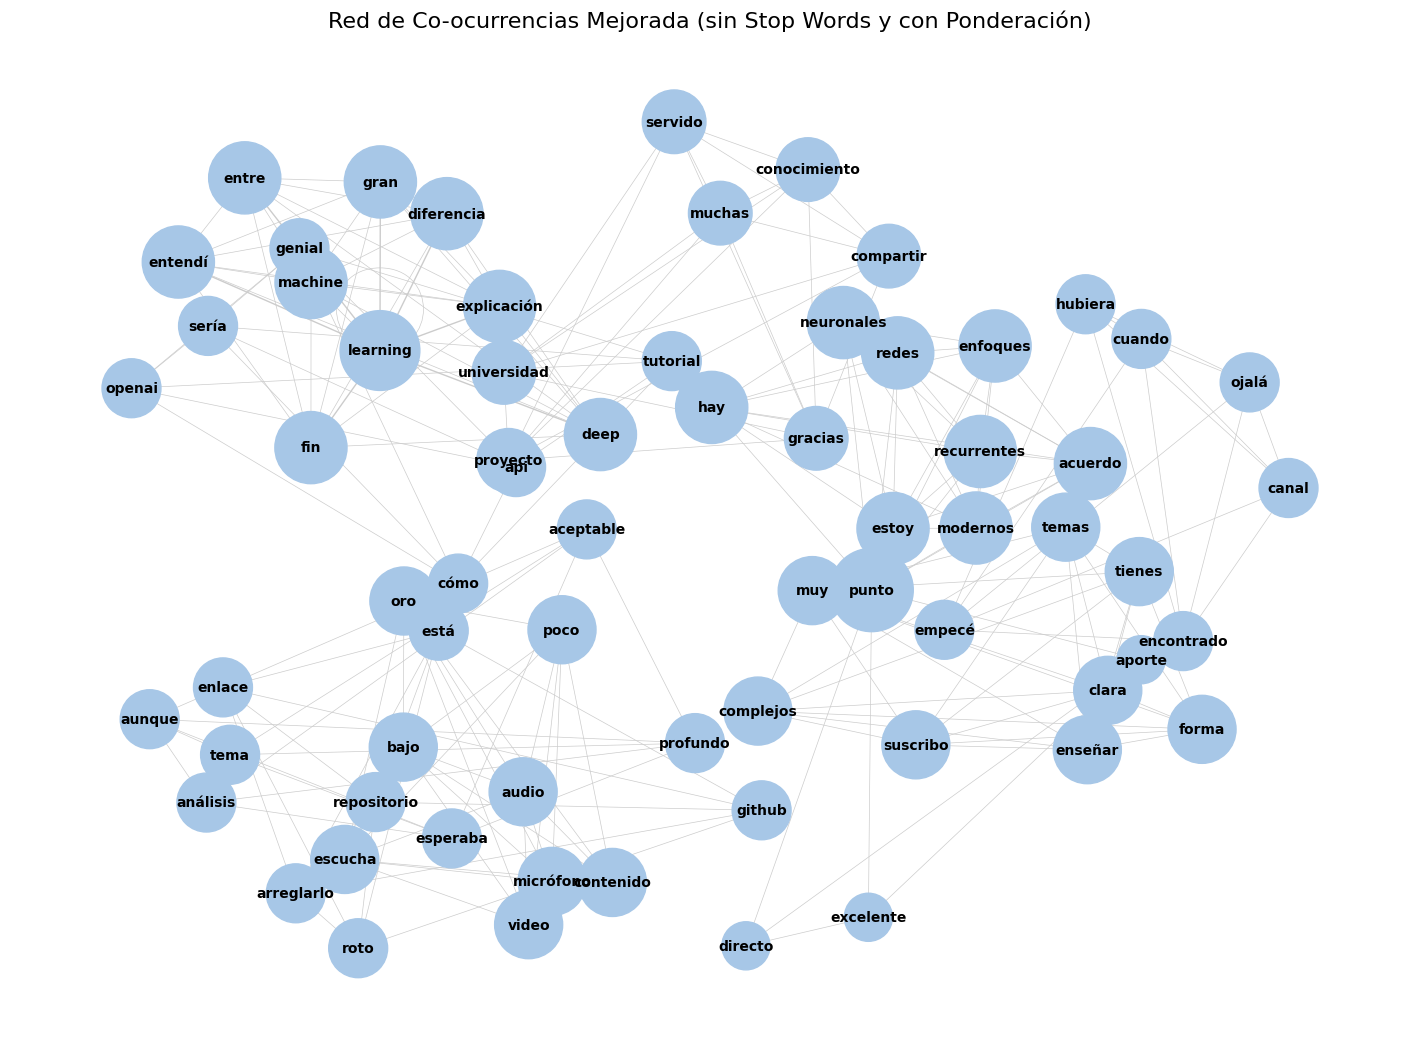

In [8]:
# =============================================================================
# SECCIÓN 5: ANÁLISIS DE CO-OCURRENCIAS (VERSIÓN MEJORADA)
# =============================================================================
print("\n\n" + "="*20 + " 5. RED DE CO-OCURRENCIAS (MEJORADA) " + "="*20)
from collections import Counter

# --- MEJORA 1: Lista de "Stop Words" en español ---
# Palabras comunes que no aportan significado y que vamos a excluir.
stopwords_es = set([
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 'un',
    'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 'sus',
    'le', 'ya', 'o', 'este', 'ha', 'me', 'si', 'sin', 'sobre', 'yo', 'también',
    'ser', 'estar', 'haber', 'tener', 'hacer', 'poder', 'decir', 'ir', 'ver',
    'dar', 'saber', 'querer', 'llegar', 'pasar', 'deber', 'poner', 'parecer',
    'quedar', 'creer', 'hablar', 'llevar', 'dejar', 'seguir', 'encontrar', 'llamar',
    'venir', 'pensar', 'salir', 'volver', 'tomar', 'conocer', 'vivir', 'sentir',
    'tratar', 'mirar', 'contar', 'empezar', 'esperar', 'buscar', 'entrar',
    'trabajar', 'escribir', 'perder', 'producir', 'ocurrir', 'entender', 'pedir',
    'recibir', 'recordar', 'terminar', 'permitir', 'aparecer', 'conseguir',
    'comenzar', 'servir', 'sacar', 'necesitar', 'mantener', 'resultar', 'leer',
    'caer', 'cambiar', 'presentar', 'crear', 'abrir', 'considerar', 'oír',
    'acabar', 'convertir', 'ganar', 'formar', 'traer', 'partir', 'morir', 'aceptar',
    'realizar', 'suponer', 'comprender', 'lograr', 'explicar', 'preguntar',
    'tocar', 'reconocer', 'estudiar', 'alcanzar', 'nacer', 'dirigir', 'correr',
    'utilizar', 'pagar', 'ayudar', 'gustar', 'jugar', 'escuchar', 'levantar', 'usar'
])

# Usamos los 'texts' de la sección anterior que ya están tokenizados
edges = []
for toks in texts:
    # --- MEJORA 2: Filtrado más robusto ---
    # Excluimos stop words, puntuación y palabras muy cortas.
    toks_filtrados = [
        tok for tok in toks
        if tok.isalpha() and len(tok) > 2 and tok not in stopwords_es
    ]
    if len(toks_filtrados) > 1:
        edges.extend(list(itertools.combinations(toks_filtrados, 2)))

# --- MEJORA 3: Ponderar las aristas (líneas) ---
# Contamos cuántas veces aparece cada par para hacer más gruesas las líneas más frecuentes.
edge_weights = Counter(edges)
weighted_edges = [(u, v, {'weight': w}) for (u, v), w in edge_weights.items()]

G = nx.Graph()
G.add_edges_from(weighted_edges)

# --- MEJORA 4: Tamaño de nodo dinámico ---
# Los nodos más conectados (más importantes) serán más grandes.
degrees = nx.degree(G)
node_sizes = [d[1] * 300 + 300 for d in degrees] # Multiplicador para ajustar el tamaño visual

# --- MEJORA 5: Ajuste del layout para evitar solapamiento ---
# 'k' controla la distancia entre nodos. Un valor más alto los separa más.
pos = nx.spring_layout(G, k=0.9, iterations=50, seed=42)

# --- MEJORA 6: Grosor de línea dinámico ---
edge_widths = [d['weight'] * 0.5 for u, v, d in G.edges(data=True)] # Multiplicador para grosor

plt.figure(figsize=(14, 10)) # Aumentamos el tamaño del lienzo
nx.draw(G, pos,
        with_labels=True,
        node_size=node_sizes,
        node_color="#a7c7e7",
        font_size=10,
        font_weight='bold',
        width=edge_widths, # Aplicamos el grosor dinámico
        edge_color="#cccccc")

plt.title("Red de Co-ocurrencias Mejorada (sin Stop Words y con Ponderación)", size=16)
print("Mostrando gráfico de la red de co-ocurrencias mejorada...")
plt.show()